In [1]:
import os
import numpy as np
import sys
import joblib
import pandas as pd

In [2]:
import torch


# Load Data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# import torch
# # import torch.nn as nn
# # import torch.optim as optim
# # import torchvision.transforms as transforms
# # from torch.utils.data import DataLoader, Dataset, random_split
# # import tifffile as tiff
# import os
# import numpy as np
# # import matplotlib.pyplot as plt
# # from sklearn.cluster import KMeans
# # from sklearn.manifold import TSNE
# # from PIL import Image
# # from tqdm import tqdm
# # from torchvision import transforms
# # from skimage import io
# import sys
# # from umap import UMAP
# import joblib
# import pandas as pd

# # Load Data
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [4]:
# Get the directory of the script
script_dir = os.getcwd()

# Get the parent directory of the script
parent_dir = os.path.dirname(script_dir)

# Add the parent directory to sys.path
sys.path.append(parent_dir)

from core.autoencoders import AE, train_ae
from core.dataset import TIFFDataset
from utils.feature_analysis import UMAP_train, patch_csv_to_AE_latent, patch_2_normed_tensor,data_to_latents, kmeans_latents,latent_to_umap,UMAP_train,DBSCAN_cluster,kmeans_cluster,dataloader_model_latents,add_features_to_latent
from utils.plotting_utils import umap_2Dplot, cluster_2Dplot



In [5]:
root_dir = '/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/results/pax_wholecell_correctloader_ch1_ps32_latdim_8_20251203_2323'
czi_base = '/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/031125data'
analysis_base = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/'

ae_path = os.path.join(root_dir,'ae_model_ep9999.pt')
ae = torch.load(ae_path, map_location=device, weights_only=False)
ae = ae.to(device)
ae.eval()

AE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.01)
    (9): Flatten(start_dim=1, end_dim=-1)
  )
  (encoder_fc): Sequential(
    (0): Linear(in_features=2048, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=8, bias=True)
  )
  (decoder_fc): Sequential(
    (0): Linear(in_features=8, out_features=1024

In [6]:
front_mask_dir = '/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/031125data/frontmasks'

In [7]:
csv_folder = analysis_base + 'ctrl_ch1_major/ctrl_ch1_patches_gridonly_wholecell_pslocation00/plot_patches32_40p_20250919_0948'
csv_filename = 'data_prep_record_49_t49.csv'
group_labels = 0
ctrl_y_str = 'ctrl'
seg_folder_str = 'code_org_20250820_seg'
cell_mask_folder = analysis_base+ctrl_y_str+'_ch1_major'+'/'+seg_folder_str+'/mask'

sub = 'Control' if ctrl_y_str == 'ctrl' else 'Ycomp'
image_folder = f"{czi_base}/{sub}"



In [8]:
if os.path.isfile(os.path.join(root_dir, 'ctrl_latent_array.pkl')):
    print('load files')
    ctrl_latent_array = joblib.load(os.path.join(root_dir, 'ctrl_latent_array.pkl'))
    ctrl_patch_label_df = pd.read_csv(os.path.join(root_dir, 'ctrl_patch_label_df.csv'))
else:
    print('make the latent and df')
    ctrl_patch_label_df, ctrl_latent_array = patch_csv_to_AE_latent(ctrl_y_str,csv_folder,csv_filename,group_labels,ae, device)
    joblib.dump(ctrl_latent_array,os.path.join(root_dir, 'ctrl_latent_array.pkl'))
    ctrl_patch_label_df.to_csv(os.path.join(root_dir, 'ctrl_patch_label_df.csv'))

make the latent and df


In [9]:
if os.path.isfile(os.path.join(root_dir, 'ctrl_latent_array_np_plus6.pkl')):    
    print('load files')
    ctrl_latent_array_np_plus6 = joblib.load(os.path.join(root_dir, 'ctrl_latent_array_np_plus6.pkl'))
    ctrl_patch_label_df = pd.read_csv(os.path.join(root_dir, 'ctrl_patch_label_df.csv'))
    ctrl_all_image_csv = pd.read_csv(os.path.join(root_dir, 'ctrl_patch_updated_record.csv'))
else:
    print('make the latent and df')
    ctrl_latent_array_np_plus6, ctrl_patch_label_df, ctrl_all_image_csv = \
        add_features_to_latent(csv_folder,csv_filename,image_folder,ctrl_y_str,cell_mask_folder,front_mask_dir,ctrl_latent_array,ctrl_patch_label_df)
    joblib.dump(ctrl_latent_array_np_plus6,os.path.join(root_dir, 'ctrl_latent_array_np_plus6.pkl'))
    ctrl_patch_label_df.to_csv(os.path.join(root_dir, 'ctrl_patch_label_df.csv'))
    ctrl_all_image_csv.to_csv(os.path.join(root_dir, 'ctrl_patch_updated_record.csv'))


make the latent and df


In [10]:
csv_folder = analysis_base + 'y_ch1_major/y_ch1_patches_gridonly_wholecell_pslocation00/plot_patches32_40p_20250919_1005'
csv_filename = 'data_prep_record_40_t40.csv'
group_labels = 1
ctrl_y_str = 'y'
seg_folder_str = 'code_org_20250820_seg'
cell_mask_folder = analysis_base + ctrl_y_str+'_ch1_major'+'/'+seg_folder_str+'/mask'

sub = 'Control' if ctrl_y_str == 'ctrl' else 'Ycomp'
image_folder = f"{czi_base}/{sub}"




In [11]:
if os.path.isfile(os.path.join(root_dir, 'y_latent_array.pkl')):
    print('load Y latent files')
    y_latent_array = joblib.load(os.path.join(root_dir, 'y_latent_array.pkl'))
    y_patch_label_df = pd.read_csv(os.path.join(root_dir, 'y_patch_label_df.csv'))
else:
    print('make the Y latent and df')
    y_patch_label_df, y_latent_array = patch_csv_to_AE_latent(ctrl_y_str,csv_folder,csv_filename,group_labels,ae,device)
    joblib.dump(y_latent_array,os.path.join(root_dir, 'y_latent_array.pkl'))
    y_patch_label_df.to_csv(os.path.join(root_dir, 'y_patch_label_df.csv'))

make the Y latent and df


In [12]:
if os.path.isfile(os.path.join(root_dir, 'y_latent_array_np_plus6.pkl')):
    print('load files')
    y_latent_array_np_plus6 = joblib.load(os.path.join(root_dir, 'y_latent_array_np_plus6.pkl'))
    y_patch_label_df = pd.read_csv(os.path.join(root_dir, 'y_patch_label_df.csv'))
    y_all_image_csv = pd.read_csv(os.path.join(root_dir, 'y_all_image_csv.csv'))
else:
    print('make the latent and df')
    y_latent_array_np_plus6, y_patch_label_df,y_all_image_csv = \
        add_features_to_latent(csv_folder,csv_filename,image_folder,ctrl_y_str,cell_mask_folder,front_mask_dir,y_latent_array,y_patch_label_df)
    joblib.dump(y_latent_array_np_plus6,os.path.join(root_dir, 'y_latent_array_np_plus6.pkl'))
    y_patch_label_df.to_csv(os.path.join(root_dir, 'y_patch_label_df.csv'))
    y_all_image_csv.to_csv(os.path.join(root_dir, 'y_all_image_csv.csv'))

make the latent and df


In [13]:
patch_label_df = pd.concat([ctrl_patch_label_df, y_patch_label_df], ignore_index=True)

latent_array = np.concatenate([ctrl_latent_array_np_plus6, y_latent_array_np_plus6])

print(latent_array.shape)

(23656, 14)


In [14]:
patch_label_df.columns

Index(['ctrl_y_str', 'crop_img_filename', 'group_labels', 'UMAP_d0', 'UMAP_d1',
       'DBSCAN_labels', 'kmeans_labels', 'vinculin_intensity', 'pax_intensity',
       'actin_intensity', 'dist_cell_edge', 'front_flag'],
      dtype='object')

In [15]:
patch_label_df['group_labels']

0        0
1        0
2        0
3        0
4        0
        ..
23651    1
23652    1
23653    1
23654    1
23655    1
Name: group_labels, Length: 23656, dtype: object

In [16]:
joblib.dump(latent_array,os.path.join(root_dir, 'latent_array_plus6_ctrl_y.pkl'))
patch_label_df.to_csv(os.path.join(root_dir, 'patch_label_df.csv'))

In [17]:
latent_array_np_plus4 = latent_array[:,:12]

In [18]:
latent_array_np_plus4.shape

(23656, 12)

In [19]:
latent_array_np_plus4[:,8] = latent_array_np_plus4[:,8]/np.percentile(latent_array_np_plus4[:,8],99)*10
latent_array_np_plus4[:,9] = latent_array_np_plus4[:,9]/np.percentile(latent_array_np_plus4[:,9],99)*10
latent_array_np_plus4[:,10] = latent_array_np_plus4[:,10]/np.percentile(latent_array_np_plus4[:,10],99)*5
latent_array_np_plus4[:,11] = latent_array_np_plus4[:,11]/np.percentile(latent_array_np_plus4[:,11],99)*5

In [20]:
latent_array_np_plus3 = latent_array[:,:11]
latent_array_np_plus3[:,8] = latent_array[:,9]/np.percentile(latent_array[:,9],99)*10
latent_array_np_plus3[:,9] = latent_array[:,10]/np.percentile(latent_array[:,10],99)*5
latent_array_np_plus3[:,10] = latent_array[:,11]/np.percentile(latent_array[:,11],99)*5


In [21]:
latent_array_np_lat8 = latent_array[:,:8]
latents_lat8_2d = UMAP_train(latent_array_np_lat8, root_dir,'vin_pax_zyx_act_data_Pax_AE_lat8only_UMAP2')

/home/ldin/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [22]:
latents_plus4_2d = UMAP_train(latent_array_np_plus4, root_dir,'vin_pax_zyx_act_data_Pax_AE_lat8_UMAP2.pkl.pkl')

/home/ldin/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [23]:
latents_plus3_2d = UMAP_train(latent_array_np_plus3, root_dir,'vin_pax_zyx_act_data_Pax_AE_lat8_plus3_UMAP2')

/home/ldin/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [24]:
root_dir

'/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/results/pax_wholecell_correctloader_ch1_ps32_latdim_8_20251203_2323'

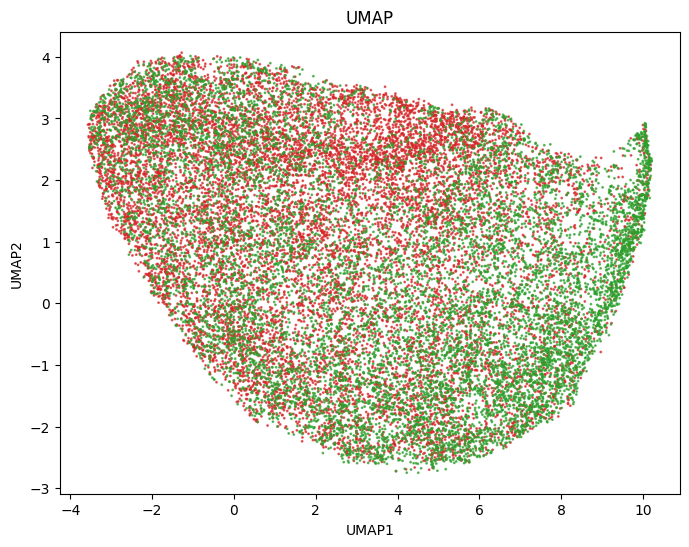

In [26]:
latents_lat8_2d
fig = umap_2Dplot(latents_lat8_2d, 0,1,1-patch_label_df['group_labels']+1)

In [27]:
front_label_to_color = {
    "Front": 3,
    "Not front": 2
}

In [28]:
patch_label_df.columns


Index(['ctrl_y_str', 'crop_img_filename', 'group_labels', 'UMAP_d0', 'UMAP_d1',
       'DBSCAN_labels', 'kmeans_labels', 'vinculin_intensity', 'pax_intensity',
       'actin_intensity', 'dist_cell_edge', 'front_flag'],
      dtype='object')

Text(0.5, 1.0, 'UMAP')

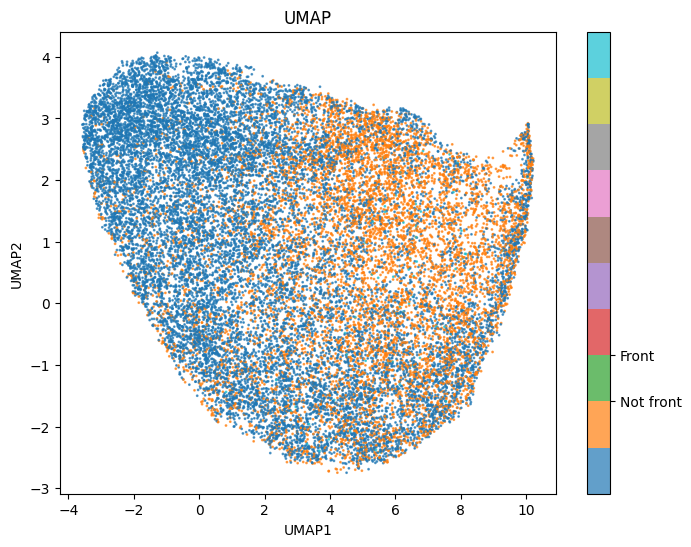

In [63]:
import matplotlib.pyplot as plt
# fig = umap_2Dplot(latents_plus3_2d, 0,1,5-patch_label_df['group_labels']*0+1)
fig = plt.figure(figsize=(8, 6))
# plt.scatter(latents_lat8_2d[:,0] , latents_lat8_2d[:,1] , c=5-patch_label_df['group_labels']*0+2, cmap='tab20', alpha=0.2, s=2, vmin=0, vmax=10)  
plt.scatter(latents_lat8_2d[:,0] , latents_lat8_2d[:,1], c=patch_label_df['front_flag']/255, cmap='tab10', alpha=0.7, s=1, vmin=0, vmax=10)

cbar = plt.colorbar()
cbar.set_ticks(list(front_label_to_color.values()))
cbar.set_ticklabels(list(front_label_to_color.keys()))
# cbar.ax.set_ylim(2, 4)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP") 

In [30]:
group_label_to_color = {
    "Control": 3.5,
    "Y-comp": 2.5
}

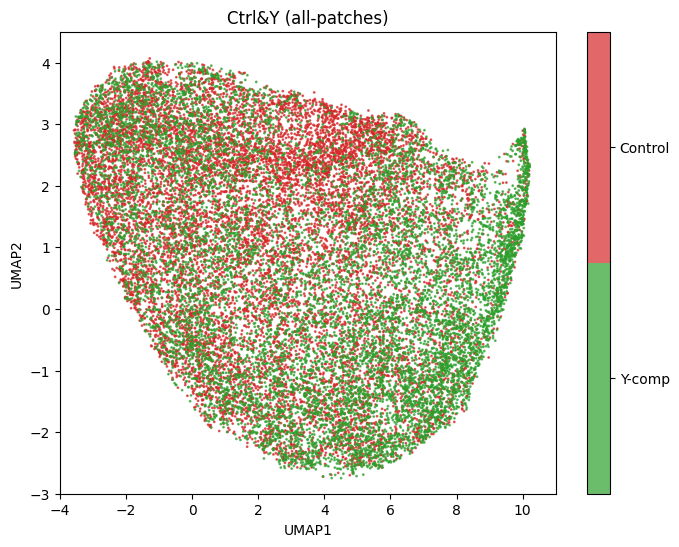

In [101]:
import matplotlib.pyplot as plt

# Filter rows where front_flag == 255
mask = patch_label_df['front_flag'] >-1
filtered_latents = latents_lat8_2d[mask]
filtered_colors = 3- patch_label_df['group_labels'][mask]  +0.5

fig = plt.figure(figsize=(8, 6))

plt.scatter(
    filtered_latents[:, 0],
    filtered_latents[:, 1],
    c=filtered_colors,
    cmap='tab10',
    alpha=0.7,
    s=1,
    vmin=0,
    vmax=10
)

cbar = plt.colorbar()
cbar.set_ticks(list(group_label_to_color.values()))
cbar.set_ticklabels(list(group_label_to_color.keys()))
cbar.ax.set_ylim(2,4)
plt.xlim(-4,11)
plt.ylim(-3,4.5)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Ctrl&Y (all-patches)")

plt.show()


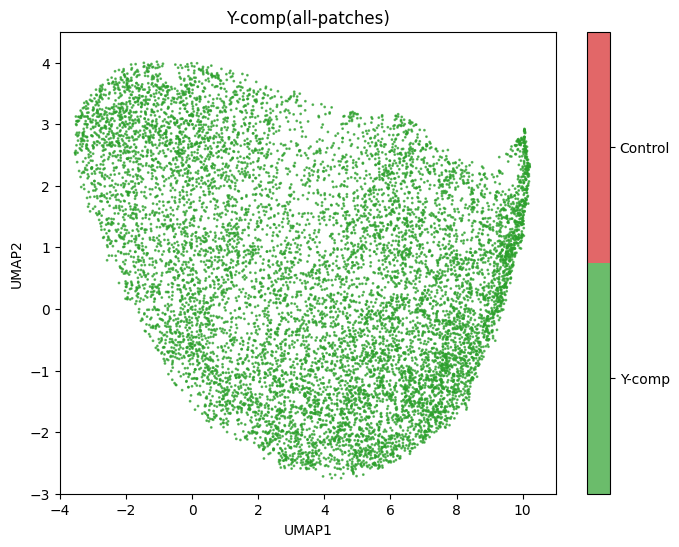

In [102]:
import matplotlib.pyplot as plt

# Filter rows where front_flag == 255
mask = (patch_label_df['front_flag'] >-1) & (patch_label_df['group_labels'] == 1)
filtered_latents = latents_lat8_2d[mask]
filtered_colors = 3 - patch_label_df['group_labels'][mask] + 0.5


fig = plt.figure(figsize=(8, 6))

plt.scatter(
    filtered_latents[:, 0],
    filtered_latents[:, 1],
    c=filtered_colors,
    cmap='tab10',
    alpha=0.7,
    s=1,
    vmin=0,
    vmax=10
)

cbar = plt.colorbar()
cbar.set_ticks(list(group_label_to_color.values()))
cbar.set_ticklabels(list(group_label_to_color.keys()))
cbar.ax.set_ylim(2,4)

plt.xlim(-4,11)
plt.ylim(-3,4.5)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Y-comp(all-patches)")

plt.show()


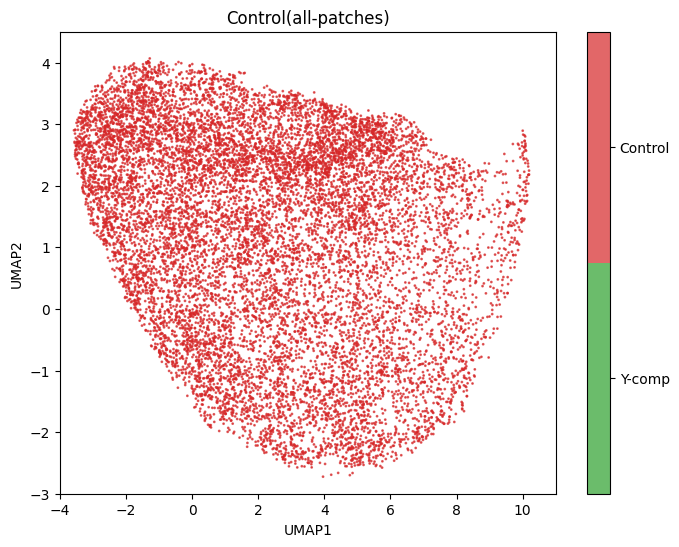

In [103]:
import matplotlib.pyplot as plt

# Filter rows where front_flag == 255
mask = (patch_label_df['front_flag'] >-1) & (patch_label_df['group_labels'] == 0)
filtered_latents = latents_lat8_2d[mask]
filtered_colors = 3 - patch_label_df['group_labels'][mask] + 0.5


fig = plt.figure(figsize=(8, 6))

plt.scatter(
    filtered_latents[:, 0],
    filtered_latents[:, 1],
    c=filtered_colors,
    cmap='tab10',
    alpha=0.7,
    s=1,
    vmin=0,
    vmax=10
)

cbar = plt.colorbar()
cbar.set_ticks(list(group_label_to_color.values()))
cbar.set_ticklabels(list(group_label_to_color.keys()))
cbar.ax.set_ylim(2,4)

plt.xlim(-4,11)
plt.ylim(-3,4.5)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Control(all-patches)")

plt.show()


In [ ]:
patch_label_df['front_flag']

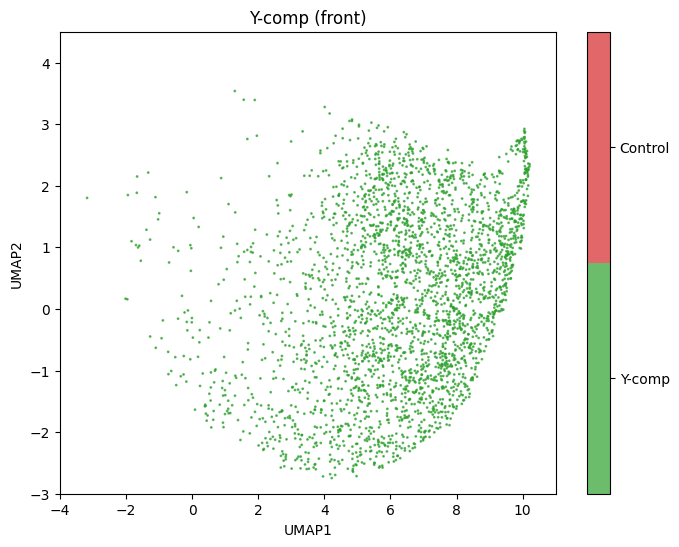

In [62]:
import matplotlib.pyplot as plt

# Filter rows where front_flag == 255
mask = (patch_label_df['front_flag'] ==255) & (patch_label_df['group_labels'] == 1)
filtered_latents = latents_lat8_2d[mask]
filtered_colors = 3 - patch_label_df['group_labels'][mask] + 0.5


fig = plt.figure(figsize=(8, 6))

plt.scatter(
    filtered_latents[:, 0],
    filtered_latents[:, 1],
    c=filtered_colors,
    cmap='tab10',
    alpha=0.7,
    s=1,
    vmin=0,
    vmax=10
)

cbar = plt.colorbar()
cbar.set_ticks(list(group_label_to_color.values()))
cbar.set_ticklabels(list(group_label_to_color.keys()))
cbar.ax.set_ylim(2,4)

plt.xlim(-4,11)
plt.ylim(-3,4.5)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Y-comp (front)")

plt.show()


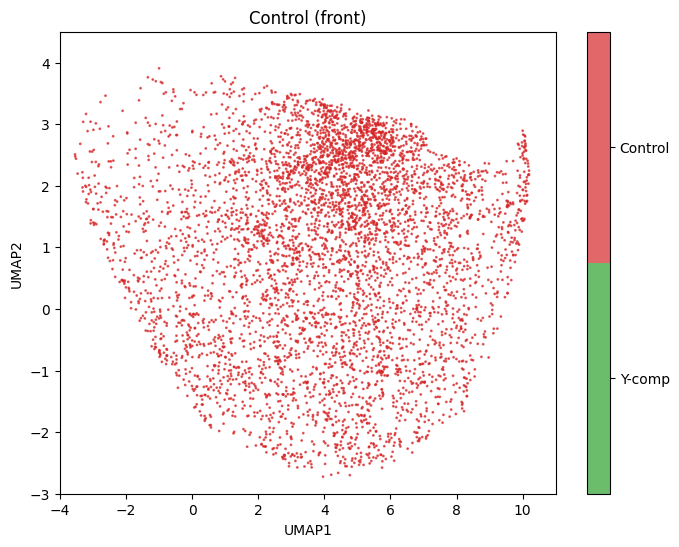

In [61]:
import matplotlib.pyplot as plt

# Filter rows where front_flag == 255
mask = (patch_label_df['front_flag'] ==255) & (patch_label_df['group_labels'] == 0)
filtered_latents = latents_lat8_2d[mask]
filtered_colors = 3 - patch_label_df['group_labels'][mask] + 0.5


fig = plt.figure(figsize=(8, 6))

plt.scatter(
    filtered_latents[:, 0],
    filtered_latents[:, 1],
    c=filtered_colors,
    cmap='tab10',
    alpha=0.7,
    s=1,
    vmin=0,
    vmax=10
)

cbar = plt.colorbar()
cbar.set_ticks(list(group_label_to_color.values()))
cbar.set_ticklabels(list(group_label_to_color.keys()))
cbar.ax.set_ylim(2,4)

plt.xlim(-4,11)
plt.ylim(-3,4.5)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Control (front)")

plt.show()


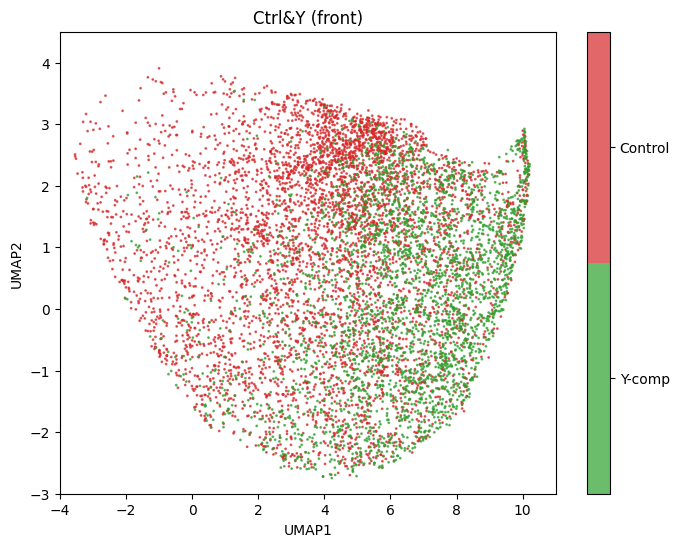

In [98]:
import matplotlib.pyplot as plt

# Filter rows where front_flag == 255
mask = (patch_label_df['front_flag'] ==255) & (patch_label_df['group_labels']>-1)
filtered_latents = latents_lat8_2d[mask]
filtered_colors = 3 - patch_label_df['group_labels'][mask] + 0.5


fig = plt.figure(figsize=(8, 6))

plt.scatter(
    filtered_latents[:, 0],
    filtered_latents[:, 1],
    c=filtered_colors,
    cmap='tab10',
    alpha=0.7,
    s=1,
    vmin=0,
    vmax=10
)

cbar = plt.colorbar()
cbar.set_ticks(list(group_label_to_color.values()))
cbar.set_ticklabels(list(group_label_to_color.keys()))
cbar.ax.set_ylim(2,4)

plt.xlim(-4,11)
plt.ylim(-3,4.5)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Ctrl&Y (front)")

plt.show()


In [40]:
patch_label_df.columns

Index(['ctrl_y_str', 'crop_img_filename', 'group_labels', 'UMAP_d0', 'UMAP_d1',
       'DBSCAN_labels', 'kmeans_labels', 'vinculin_intensity', 'pax_intensity',
       'actin_intensity', 'dist_cell_edge', 'front_flag'],
      dtype='object')

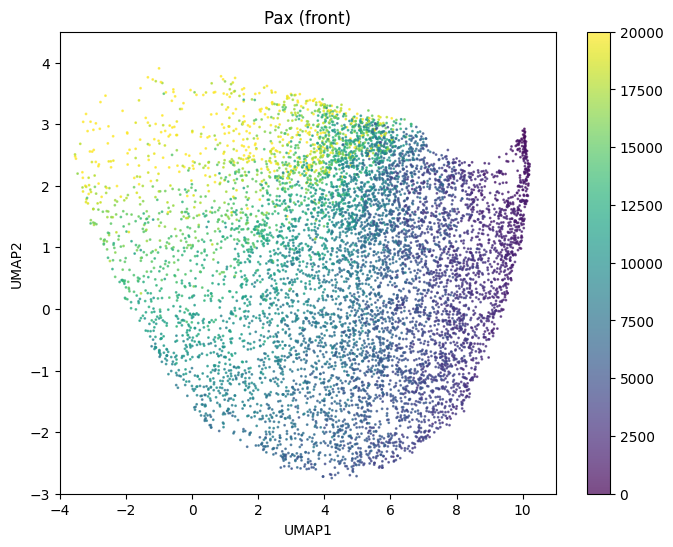

In [60]:
import matplotlib.pyplot as plt

# Filter rows where front_flag == 255
mask = (patch_label_df['front_flag']==255) & (patch_label_df['group_labels']>-1)
filtered_latents = latents_lat8_2d[mask]
filtered_colors = patch_label_df['pax_intensity'][mask]


fig = plt.figure(figsize=(8, 6))

plt.scatter(
    filtered_latents[:, 0],
    filtered_latents[:, 1],
    c=filtered_colors,
    # cmap='tab10',
    alpha=0.7,
    s=1,
    vmin=0,
    vmax=20000
)

cbar = plt.colorbar()
# cbar.set_ticks(list(group_label_to_color.values()))
# cbar.set_ticklabels(list(group_label_to_color.keys()))
# cbar.ax.set_ylim(2,4)

plt.xlim(-4,11)
plt.ylim(-3,4.5)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Pax (front)")

plt.show()


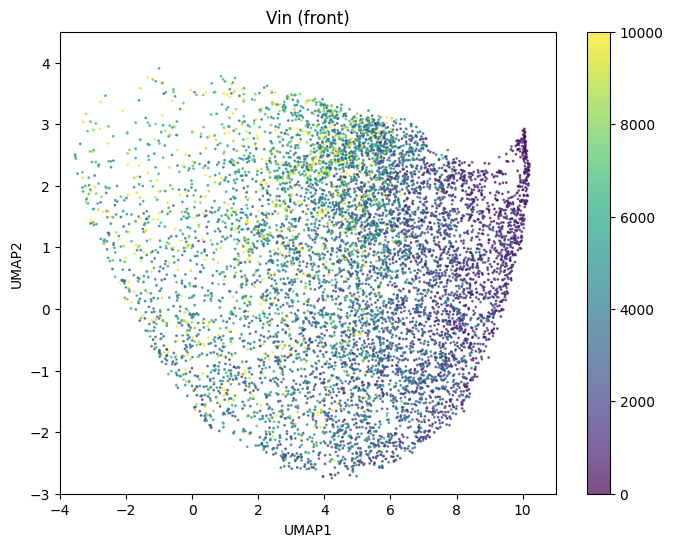

In [57]:
import matplotlib.pyplot as plt

# Filter rows where front_flag == 255
mask = (patch_label_df['front_flag']==255) & (patch_label_df['group_labels']>-1)
filtered_latents = latents_lat8_2d[mask]
filtered_colors = patch_label_df['vinculin_intensity'][mask]


fig = plt.figure(figsize=(8, 6))

plt.scatter(
    filtered_latents[:, 0],
    filtered_latents[:, 1],
    c=filtered_colors,
    # cmap='tab10',
    alpha=0.7,
    s=1,
    vmin=0,
    vmax=10000
)

cbar = plt.colorbar()
# cbar.set_ticks(list(group_label_to_color.values()))
# cbar.set_ticklabels(list(group_label_to_color.keys()))
# cbar.ax.set_ylim(2,4)

plt.xlim(-4,11)
plt.ylim(-3,4.5)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Vin (front)")

plt.show()


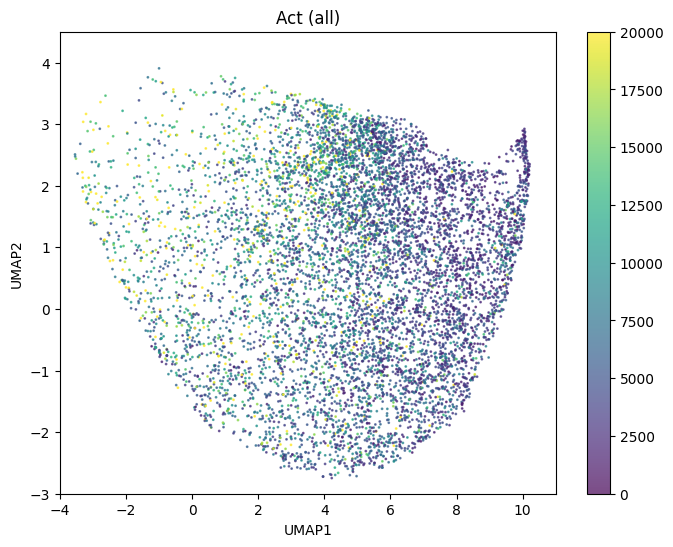

In [58]:
import matplotlib.pyplot as plt

# Filter rows where front_flag == 255
mask = (patch_label_df['front_flag']==255) & (patch_label_df['group_labels']>-1)
filtered_latents = latents_lat8_2d[mask]
filtered_colors = patch_label_df['actin_intensity'][mask]


fig = plt.figure(figsize=(8, 6))

plt.scatter(
    filtered_latents[:, 0],
    filtered_latents[:, 1],
    c=filtered_colors,
    # cmap='tab10',
    alpha=0.7,
    s=1,
    vmin=0,
    vmax=20000
)

cbar = plt.colorbar()
# cbar.set_ticks(list(group_label_to_color.values()))
# cbar.set_ticklabels(list(group_label_to_color.keys()))
# cbar.ax.set_ylim(2,4)

plt.xlim(-4,11)
plt.ylim(-3,4.5)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Act (all)")

plt.show()


In [80]:
kmeans_num_clusters=4
eps=2
min_samples=5
kmeans, kmeans_labels = kmeans_cluster(latent_array_np_lat8, kmeans_num_clusters, root_dir,'vindata_pax_AE_lat8_trainval42_kmeans')
DBSCAN, DBSCAN_labels =  DBSCAN_cluster(latent_array_np_lat8, eps, min_samples, root_dir,'vindata_pax_AE_lat8_trainval42_DSN')


In [104]:
kmeans_num_clusters=20
kmeans, kmeans_labels = kmeans_cluster(latent_array_np_lat8, kmeans_num_clusters, root_dir,'vindata_pax_AE_lat8_trainval42_kmeans')



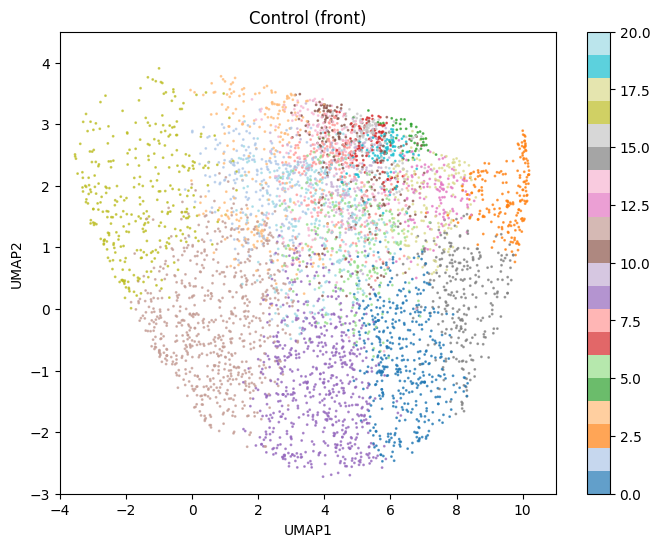

In [107]:
import matplotlib.pyplot as plt

# Filter rows where front_flag == 255
mask = (patch_label_df['front_flag']==255) & (patch_label_df['group_labels']==0)
filtered_latents = latents_lat8_2d[mask]
filtered_colors = kmeans_labels[mask]


fig = plt.figure(figsize=(8, 6))

plt.scatter(
    filtered_latents[:, 0],
    filtered_latents[:, 1],
    c=filtered_colors,
    cmap='tab20',
    alpha=0.7,
    s=1,
    vmin=0,
    vmax=20
)

cbar = plt.colorbar()
# cbar.set_ticks(list(group_label_to_color.values()))
# cbar.set_ticklabels(list(group_label_to_color.keys()))
# cbar.ax.set_ylim(0,4)

plt.xlim(-4,11)
plt.ylim(-3,4.5)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Control (front)")

plt.show()


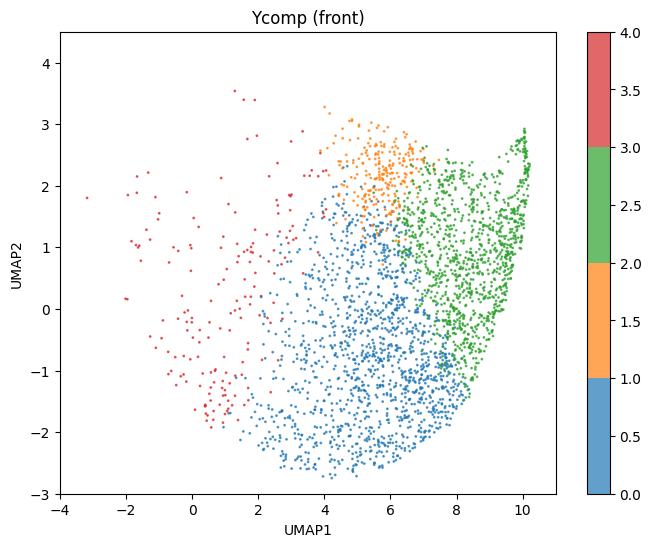

In [91]:
import matplotlib.pyplot as plt

# Filter rows where front_flag == 255
mask = (patch_label_df['front_flag']==255) & (patch_label_df['group_labels']==1)
filtered_latents = latents_lat8_2d[mask]
filtered_colors = kmeans_labels[mask]


fig = plt.figure(figsize=(8, 6))

plt.scatter(
    filtered_latents[:, 0],
    filtered_latents[:, 1],
    c=filtered_colors,
    cmap='tab10',
    alpha=0.7,
    s=1,
    vmin=0,
    vmax=10
)

cbar = plt.colorbar()
# cbar.set_ticks(list(group_label_to_color.values()))
# cbar.set_ticklabels(list(group_label_to_color.keys()))
cbar.ax.set_ylim(0,4)

plt.xlim(-4,11)
plt.ylim(-3,4.5)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Ycomp (front)")

plt.show()


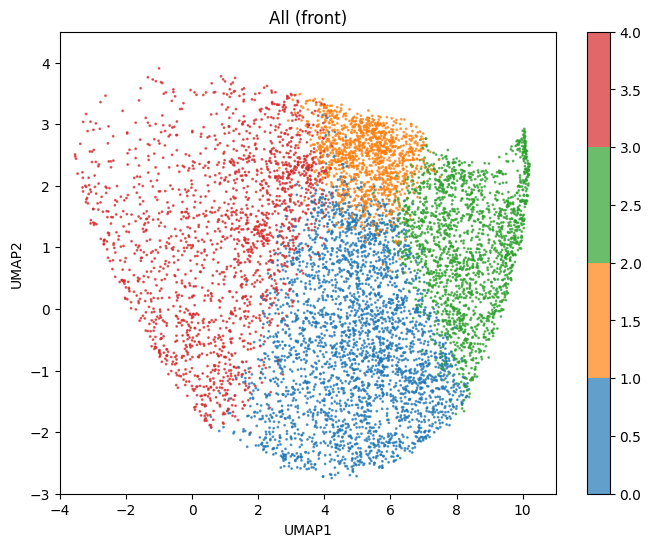

In [93]:
import matplotlib.pyplot as plt

# Filter rows where front_flag == 255
mask = (patch_label_df['front_flag']==255) & (patch_label_df['group_labels']>-1)
filtered_latents = latents_lat8_2d[mask]
filtered_colors = kmeans_labels[mask]


fig = plt.figure(figsize=(8, 6))

plt.scatter(
    filtered_latents[:, 0],
    filtered_latents[:, 1],
    c=filtered_colors,
    cmap='tab10',
    alpha=0.7,
    s=1,
    vmin=0,
    vmax=10
)

cbar = plt.colorbar()
# cbar.set_ticks(list(group_label_to_color.values()))
# cbar.set_ticklabels(list(group_label_to_color.keys()))
cbar.ax.set_ylim(0,4)

plt.xlim(-4,11)
plt.ylim(-3,4.5)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("All (front)")

plt.show()


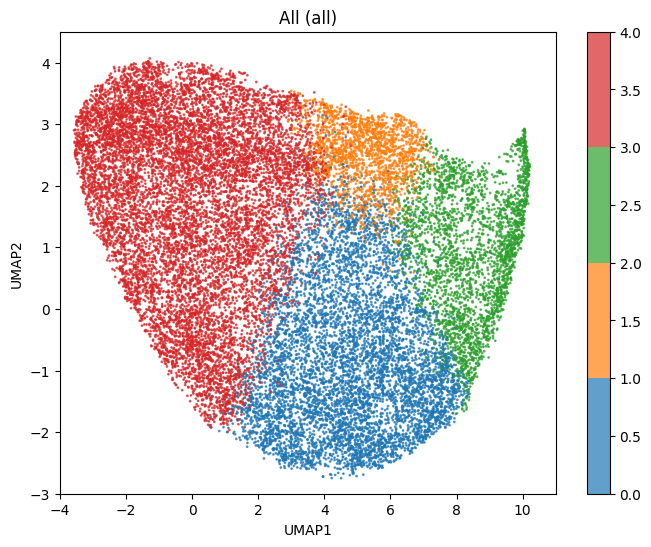

In [94]:
import matplotlib.pyplot as plt

# Filter rows where front_flag == 255
mask = (patch_label_df['front_flag']>-1) & (patch_label_df['group_labels']>-1)
filtered_latents = latents_lat8_2d[mask]
filtered_colors = kmeans_labels[mask]


fig = plt.figure(figsize=(8, 6))

plt.scatter(
    filtered_latents[:, 0],
    filtered_latents[:, 1],
    c=filtered_colors,
    cmap='tab10',
    alpha=0.7,
    s=1,
    vmin=0,
    vmax=10
)

cbar = plt.colorbar()
# cbar.set_ticks(list(group_label_to_color.values()))
# cbar.set_ticklabels(list(group_label_to_color.keys()))
cbar.ax.set_ylim(0,4)

plt.xlim(-4,11)
plt.ylim(-3,4.5)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("All (all)")

plt.show()


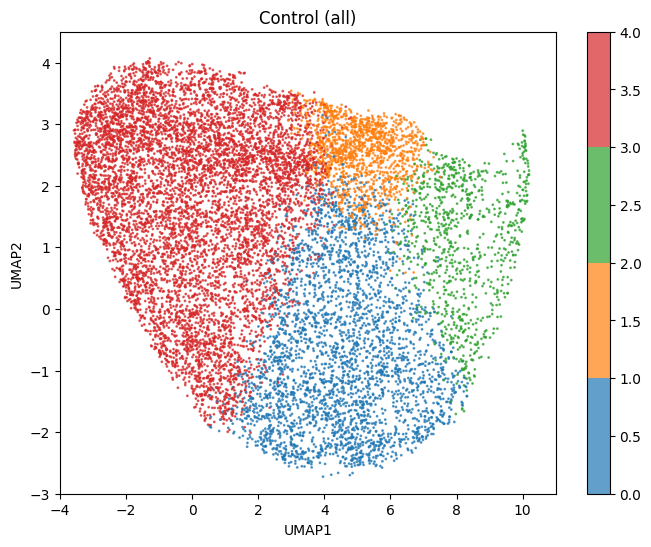

In [95]:
import matplotlib.pyplot as plt

# Filter rows where front_flag == 255
mask = (patch_label_df['front_flag']>-1) & (patch_label_df['group_labels']==0)
filtered_latents = latents_lat8_2d[mask]
filtered_colors = kmeans_labels[mask]


fig = plt.figure(figsize=(8, 6))

plt.scatter(
    filtered_latents[:, 0],
    filtered_latents[:, 1],
    c=filtered_colors,
    cmap='tab10',
    alpha=0.7,
    s=1,
    vmin=0,
    vmax=10
)

cbar = plt.colorbar()
# cbar.set_ticks(list(group_label_to_color.values()))
# cbar.set_ticklabels(list(group_label_to_color.keys()))
cbar.ax.set_ylim(0,4)

plt.xlim(-4,11)
plt.ylim(-3,4.5)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Control (all)")

plt.show()


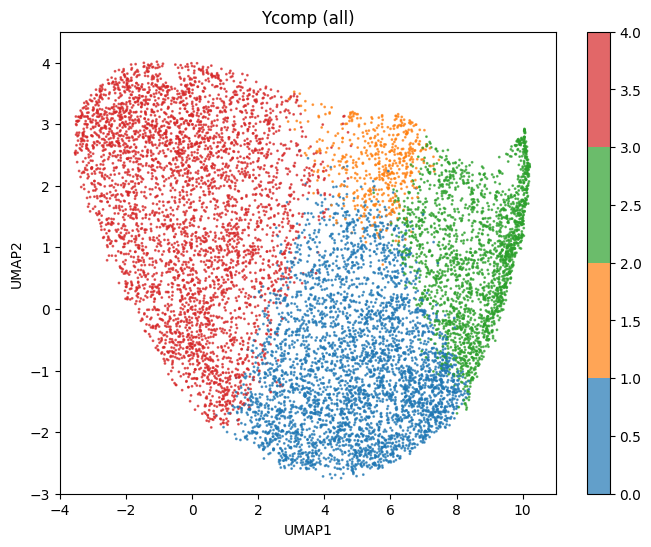

In [96]:
import matplotlib.pyplot as plt

# Filter rows where front_flag == 255
mask = (patch_label_df['front_flag']>-1) & (patch_label_df['group_labels']==1)
filtered_latents = latents_lat8_2d[mask]
filtered_colors = kmeans_labels[mask]


fig = plt.figure(figsize=(8, 6))

plt.scatter(
    filtered_latents[:, 0],
    filtered_latents[:, 1],
    c=filtered_colors,
    cmap='tab10',
    alpha=0.7,
    s=1,
    vmin=0,
    vmax=10
)

cbar = plt.colorbar()
# cbar.set_ticks(list(group_label_to_color.values()))
# cbar.set_ticklabels(list(group_label_to_color.keys()))
cbar.ax.set_ylim(0,4)

plt.xlim(-4,11)
plt.ylim(-3,4.5)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Ycomp (all)")

plt.show()
